In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# Use pandas.read_csv() to create a dataframe named nfa_df from the dataset at 
# URL: /kaggle/input/nfa-2017-editione/footprint-nfa-2017-edition/NFA 2017 Edition.csv

nfa_df = pd.read_csv('/kaggle/input/nfa-2017/NFA 2017 Edition.csv')
nfa_df

## Exercise 1 Create a Histogram

In [ ]:
# Select all Ecological Footprint of Consumption per Capita records for all countries at 2013
efcons_df = nfa_df.loc[(nfa_df['record'] == 'EFConsPerCap') \
                     & (nfa_df['year'] == 2013)]

# Create a non-cumulative histogram for the total Ecological Footprint of Consumption per Capita records at 2013
# (the column named total in efcons_df) with 10 bins

# Replace this line with your code
efcons_df.hist(column=['total'], cumulative=False, bins=10)

## Exercise 2 Obtain a Summary of Descriptive Statistics

In [ ]:
# Create a summary of descriptive statistics for the total Ecological Footprint of Consumption per Capita records at 2013
# (the column named total in efcons_df)

# Replace this line with your code
efcons_df['total'].describe()

## Exercise 3 Calculate z-Scores

In [ ]:
# Import the stats library from the scipy package
from scipy import stats

# Caculate the z-Scores for the total Ecological Footprint of Consumption per Capita records at 2013
# (the column named total in efcons_df)

# Replace this line with your code
stats.zscore(efcons_df['total'])

## Exercise 4 Identify Outliers through the Box Plot

In [ ]:
# Import the seaborn and matplotlib.pyplot packages for data viasualization
import seaborn as sns
import matplotlib.pyplot as plt

# Set the size of the plot
plt.figure(figsize=(6,8))

# Use seaborn.boxplot() to create a box plot for the total Ecological Footprint of Consumption per Capita records at 2013
# (the column named total in efcons_df)

# Replace this line with your code
sns.boxplot(data=efcons_df, y='total', orient='v')

In [ ]:
# Use the conditional index to examine the two outliers highlighted in the box plot

# Replace this line with your code
efcons_df.loc[(efcons_df['total'] > 12)]

In [ ]:
# Alternatively, sort the total and display the first two rows

efcons_df.sort_values(by=['total'], ascending=False).head(2)

In [ ]:
# z-score = (data - mean) / standard deviation

from scipy import stats

efcons_df.loc[(stats.zscore(efcons_df['total']) > 3) \
            | (stats.zscore(efcons_df['total']) < -3)]

# Use between() to make the condition shorter
# efcons_df.loc[stats.zscore(efcons_df['total']).between(-3, 3) == False]

# Use abs() to make the condition shorter
# efcons_df.loc[stats.zscore(efcons_df['total']).abs() > 3]

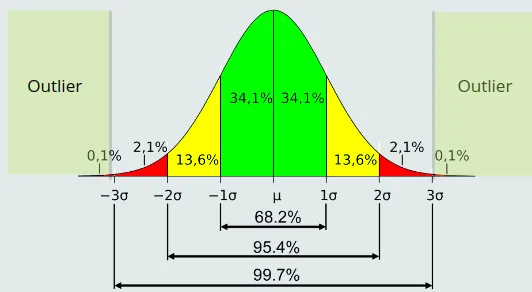

## [Optional] Exercise 5 Create Multiple Box Plots

In [ ]:
# Use pandas.DataFrame.loc[] to create a dataframe named efcons_period_df for records 
# of the Ecological Footprint of Consumption per Capita (EFConsPerCap) since 2000 for China and the World

# Hint: Use pandas.Series.isin() to select rows that contains China or the World in the country column

# Replace this line with your code
efcons_period_df = nfa_df.loc[(nfa_df['record'] == 'EFConsPerCap') \
                              & (nfa_df['year'] >= 2000) \
                              & (nfa_df['country'].isin(['China', 'World']))]

# (nfa_df['country'].isin(['China', 'World'])) is equivalent to 
# ((nfa_df['country'] == 'China') | (nfa_df['country'] == 'World'))

# Use seaborn.boxplot() to create two box plots side-by-side in the same figure for 
# the Ecological Footprint of Consumption per Capita (EFConsPerCap) since 2000 for China and the World

# Replace this line with your code
sns.boxplot(data=efcons_period_df, x='country', y='total', orient='v')

## [Optional] Implication 1
What is the implication can you draw from comparing the two box plots of the Ecological Footprint of Consumption per Capita?

**Exemplary Answer:**
> **The size of Ecological Footprint of Consumption per Capita in China surpassed the world average during the period from 2000 to 2013.**

## Exercise 6 Create a Scatter Plot

In [ ]:
# Use pandas.DataFrame.loc[] to create a dataframe named efcons_full_df for all records 
# of the Ecological Footprint of Consumption per Capita (EFConsPerCap) for China and the World

# Replace this line with your code
efcons_full_df = nfa_df.loc[(nfa_df['record'] == 'EFConsPerCap') \
                          & (nfa_df['country'].isin(['China', 'World']))]

# Use seaborn.scatterplot() to create a scatter plot to visualize the annual change of total EFConsPerCap for China and the World
# Set the year column as the x-axis and the total column as the y-axis

# Hint: Set hue='country' to plot data points for China and the World in different colors

# Replace this line with your code
sns.scatterplot(data=efcons_full_df, x='year', y='total', hue='country')

## Exercise 7 Create a Covariance Matrix

In [ ]:
# Use pandas.DataFrame.loc[] to create a dataframe named efcons_cov_df for all records 
# of the Ecological Footprint of Consumption per Capita (EFConsPerCap) since 2000

# Replace this line with your code
efcons_cov_df = nfa_df.loc[(nfa_df['record'] == 'EFConsPerCap') \
                         & (nfa_df['year'] >= 2000)]

# Use pandas.DataFrame.cov() to create a covariance matrix for the followng columns of efcons_cov_df:
# ['year', 'crop_land', 'grazing_land', 'forest_land', 'fishing_ground', 'built_up_land', 'carbon' ,'total']

# Replace this line with your code
efcons_cov_df.loc[:,['year', 'crop_land', 'grazing_land', 'forest_land', \
                     'fishing_ground', 'built_up_land', 'carbon' ,'total']].cov()

# efcons_cov_df[['year', 'crop_land', 'grazing_land', 'forest_land', 'fishing_ground', 'built_up_land', 'carbon' ,'total']].cov()

## Exercise 8 Create a Correlation Matrix

In [ ]:
# Use pandas.DataFrame.corr() to create a correlation matrix for the followng columns of efcons_cov_df:
# ['year', 'crop_land', 'grazing_land', 'forest_land', 'fishing_ground', 'built_up_land', 'carbon' ,'total']

# Replace this line with your code
efcons_cov_df.loc[:,['year', 'crop_land', 'grazing_land', 'forest_land',\
                     'fishing_ground', 'built_up_land', 'carbon' ,'total']].corr()

# efcons_cov_df[['year', 'crop_land', 'grazing_land', 'forest_land', \
#                    'fishing_ground', 'built_up_land', 'carbon' ,'total']].corr()

## Exercise 9 Clear Missing Values

In [ ]:
# Use pandas.DataFrame.loc[] to select rows containing missing values in the column named carbon in efcons_cov_df

# Replace this line with your code
efcons_cov_df.loc[(efcons_cov_df['carbon'].isna())]

In [ ]:
# Use pandas.DataFrame.dropna() to remove rows containing missing from efcons_cov_df

# Replace this line with your code
efcons_cov_df = efcons_cov_df.dropna()

efcons_cov_df

## Exercise 10 Calculate Correlational Coefficients with p-Values

In [ ]:
# Use stats.pearsonr() to calculate the correlation coefficient between 
# the Carbon Footprint (carbon) and the Built Up Land (built_up_land) in efcons_cov_df and its p-Value

# Replace this line with your code
stats.pearsonr(efcons_cov_df['carbon'], efcons_cov_df['built_up_land'])

In [ ]:
# get the correlation coefficient only
stats.pearsonr(efcons_cov_df['carbon'], efcons_cov_df['built_up_land'])[0]

In [ ]:
# get the p-value only
stats.pearsonr(efcons_cov_df['carbon'], efcons_cov_df['built_up_land'])[1]

## Implication 2

What is the implication that you may draw from the correlation between the Carbon Footprint and the Built Up Land

**Exemplary Answer:**
> **The size of Carbon Footprint is positively associated with the area of the Built Up Land. This positive association means that urbanization creates carbon emission.**

## [Optional] Exercise 11 Calculate Correlational Coefficients for Seperate Dataframes

In [ ]:
# Use pandas.DataFrame.loc[] to create a dataframe named area_df for all records 
# of the Surface Area (AreaTotHA) at 2013

# Replace this line with your code
area_df = nfa_df.loc[(nfa_df['record'] == 'AreaTotHA') \
                   & (nfa_df['year'] == 2013)]

area_df

In [ ]:
# Use pandas.DataFrame.loc[] to create a dataframe named efcons_df for all records 
# of the total Ecological Footprint of Consumption (EFConsTotGHA) at 2013

# Replace this line with your code
efcons_df = nfa_df.loc[(nfa_df['record'] == 'EFConsTotGHA') \
                     & (nfa_df['year'] == 2013)]

efcons_df

In [ ]:
# Use pandas.merge() to join efcons_df with area_df on the column named country into merge_df
merge_df = pd.merge(efcons_df, area_df, on=['country'], suffixes=("_ef", "_area"))

# Use pandas.DataFrame.dropna() to remove rows containing missing values from merge_df

# Replace this line with your code
merge_df = merge_df.dropna()

merge_df

In [ ]:
merge_df.info()

In [ ]:
# Use stats.pearsonr() to calculate the correlation coefficient between 
# the Carbon Footprint (carbon_ef) and the total Surface Area (total_area) in merge_df and its p-Value

# Replace this line with your code
stats.pearsonr(merge_df['carbon_ef'], merge_df['total_area'])

In [ ]:
# Use seaborn.scatterplot() to create a scatter plot to visualize the relationship between 
# the Carbon Footprint (carbon_ef) and the total Surface Area (total_area) for China and the World
# Set the total_area column as the x-axis and the carbon_ef column as the y-axis

# Replace this line with your code
sns.scatterplot(data=merge_df, x='total_area', y='carbon_ef')

## [Optional] Implication 3

What is the implication that you may draw from the correlation between the Carbon Footprint and the total Surface Area

**Exemplary Answer:**
> **The size of Carbon Footprint of a country is positively associated with its surface area. This positive association means that larger countreis tend to create more carbon emission.**

## [Optional] Exercise 12 Calculate Correlational Coefficients for per Capita Records and Compare and Results

In [ ]:
# Use pandas.DataFrame.loc[] to create a dataframe named area_df for all records 
# of the Surface Area per Capita (AreaPerCap) at 2013

# Replace this line with your code
area_df = nfa_df.loc[(nfa_df['record'] == 'AreaPerCap') \
                   & (nfa_df['year'] == 2013)]

area_df

In [ ]:
# Use pandas.DataFrame.loc[] to create a dataframe named efcons_df for all records 
# of the Ecological Footprint of Consumption per Capita (EFConsPerCap) at 2013

# Replace this line with your code
efcons_df = nfa_df.loc[(nfa_df['record'] == 'EFConsPerCap') \
                     & (nfa_df['year'] == 2013)]

efcons_df

In [ ]:
# Use pandas.merge() to join efcons_df with area_df on the column named country into merge_df
merge_df = pd.merge(efcons_df, area_df, on=['country'], suffixes=("_ef", "_area"))

# Use pandas.DataFrame.dropna() to remove rows containing missing values from merge_df

# Replace this line with your code
merge_df = merge_df.dropna()

merge_df

In [ ]:
merge_df.info()

In [ ]:
# Use stats.pearsonr() to calculate the correlation coefficient between 
# the Carbon Footprint per Capita (carbon_ef) and the Surface Area per Capita (total_area) in merge_df and its p-Value

# Replace this line with your code
stats.pearsonr(merge_df['carbon_ef'], merge_df['total_area'])

In [ ]:
# Use seaborn.scatterplot() to create a scatter plot to visualize the relationship between 
# the Carbon Footprint per Capita (carbon_ef) and the total Surface Area per Capita (total_area) for China and the World
# Set the total_area column as the x-axis and the carbon_ef column as the y-axis

# Replace this line with your code
sns.scatterplot(data=merge_df, x='total_area', y='carbon_ef')

## [Optional] Implication 4

Whether the correlation between the Carbon Footprint per Capita and the Surface Area per Capita changes your answer to Implication 3? If yes, explain why.

**Exemplary Answer:**
> **Yes. The association between Carbon Footprint and Surface Area becomes non-significant if we take into consideration the population size of each country. This observation suggests that countries with more people, rather than a larger absolute surface area, tend to produce a higher carbon emission.**